## 2D two layer network for Simple Cells  

1. Import utils

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *
#np.random.seed(seed=100)

2. Build net


In [26]:
np.random.seed(seed=187)

#############################
#          Params           #
#############################
N_L0_E = 19600
N_L0_I = 19600  
N_L1_E = 62500
N_L1_I = 62500          
N_L2_E = 20000
N_L3_E = 1

N = (N_L0_E+N_L0_I, N_L1_E+N_L1_I, N_L2_E, N_L3_E)
n = int(N_L0_E**(1/2))                   
sig = 0.00001
K = 1

sig_0_E = 0.015
sig_0_I = 0.045
sig_1_E = 0.02
sig_1_I = 0.04
sig_2_E = 0.03

sig_1_x_E = 0.08
sig_1_y_E = sig
sig_1_x_I = 0.08
sig_1_y_I = sig
sig_2_x_E = sig
sig_2_y_E = 0.20

sig_00 =  0.003          
sig_11 =  0.003
sig_22 =  0.003 

n_angles = 2
angles = np.linspace(0, 1, n_angles, endpoint=False)
probs = np.full(n_angles, 1/n_angles)

p_0 = 1

w_0_E =  1.0/(N_L0_E*np.pi*((sig_0_E)**2)*p_0)  * 0.8
w_0_I =  -1.0/(N_L0_I*np.pi*((sig_0_I)**2)*p_0) * 0.4

w_1_E =  1.0/(N_L1_E*(1/len(angles))*(1/(1+sig_1_x_E))*np.pi*(sig_1_E**2)*p_0)  *3      #* 2.5
w_1_I =  -1.0/(N_L1_I*(1/len(angles))*(1/(1+sig_1_x_E))*np.pi*(sig_1_I**2)*p_0) *2      #* 1.5

w_2_E   = 1.0/(N_L2_E*(1/len(angles))*(1/(1+sig_1_x_E))*np.pi*(sig_2_E**2)*p_0) *6

w_00  =  1.0/(N_L0_E*np.pi*((sig_00)**2)*p_0)   
w_11  =  1.0/(N_L1_E*np.pi*((sig_11)**2)*p_0)   


#############################
#        Create Net         #
#############################


# layer 0 
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

# layer 1

# ext
xy_E    = np.random.rand(N_L1_E, 2)
theta_E = np.random.choice(angles, size=N_L1_E, p=probs)*np.pi

#xy_E[:,0] =  xy_E[:,1] = 0.5

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)
th_lig_E = theta_E + sig * np.random.randn(N_L1_E)
th_rec_E = theta_E + sig * np.random.randn(N_L1_E)

noise_theta = warp_coords(np.random.randn(N_L1_E, 2), th_rec_E, sig_1_x_E, sig_1_y_E)
layer_rec_xy_E = xy_lig_E + noise_theta

layer_lig_3d_E = np.column_stack((xy_lig_E, th_lig_E))
layer_rec_3d_E = np.column_stack((layer_rec_xy_E, th_rec_E))

# inh
xy_I    = np.random.rand(N_L1_I, 2)
theta_I = np.random.choice(angles, size=N_L1_I, p=probs)*np.pi

xy_lig_I = xy_I + sig * np.random.randn(N_L1_I, 2)
xy_rec_I = xy_I + sig * np.random.randn(N_L1_I, 2)
th_lig_I = theta_I + sig * np.random.randn(N_L1_I)
th_rec_I = theta_I + sig * np.random.randn(N_L1_I)

noise_theta = warp_coords(np.random.randn(N_L1_I, 2), th_rec_I, sig_1_x_I, sig_1_y_I)
layer_rec_xy_I = xy_lig_I + noise_theta

layer_lig_3d_I = np.column_stack((xy_lig_I, th_lig_I))
layer_rec_3d_I = np.column_stack((layer_rec_xy_I, th_rec_I))

layer_lig_3d_combined = np.vstack((layer_lig_3d_E, layer_lig_3d_I))
layer_rec_3d_combined = np.vstack((layer_rec_3d_E, layer_rec_3d_I))

net.append([layer_lig_3d_combined, layer_rec_3d_combined])

# layer 2

xy_L2_E    = np.random.rand(N_L2_E, 2)
theta_L2_E = np.random.choice(angles, size=N_L2_E, p=probs)*np.pi

xy_lig_L2_E = xy_L2_E + sig * np.random.randn(N_L2_E, 2)
xy_rec_L2_E = xy_L2_E + sig * np.random.randn(N_L2_E, 2)
th_lig_L2_E = theta_L2_E + sig * np.random.randn(N_L2_E)
th_rec_L2_E = theta_L2_E + sig * np.random.randn(N_L2_E)

noise_theta = warp_coords(np.random.randn(N_L2_E, 2), th_rec_L2_E, sig_2_x_E, sig_2_y_E)
layer_rec_xy_L2_E = xy_lig_L2_E + noise_theta

layer_lig = np.column_stack((xy_lig_L2_E, th_lig_L2_E))
layer_rec = np.column_stack((layer_rec_xy_L2_E, th_rec_L2_E))

net.append([layer_lig, layer_rec])

# z = np.random.rand(N_L2_E, 3)
# z[:,2] = np.random.choice(angles, size=N_L2_E, p=probs)*np.pi


# #z[:,0] =  z[:,1] = 0.5
 
# layer_lig = z + (sig * np.random.randn(N_L2_E, 3))
# layer_rec = z + (sig * np.random.randn(N_L2_E, 3))

# net.append([layer_lig, layer_rec])


# layer 3

z = np.random.rand(N_L3_E, 3)
z[:,2] = np.random.choice(angles, size=N_L3_E, p=probs)*np.pi

z[:,0] =  z[:,1] = 0.5

layer_lig = z + (sig * np.random.randn(N_L3_E, 3))
layer_rec = z + (sig * np.random.randn(N_L3_E, 3))

net.append([layer_lig, layer_rec])


#############################
#  Create Connectivity      #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0][0:N_L1_E, :2]
l_vals_L1_I = net[1][0][N_L1_E:, :2]
l_vals_L1_I_3d = net[1][0][N_L1_E:]
r_vals_L1_E = net[1][1][0:N_L1_E]
r_vals_L1_I = net[1][1][N_L1_E:]
l_vals_L2   = net[2][0]
l_vals_L2_E    = net[2][0]    
r_vals_L2_E    = net[2][1]     
l_vals_L3      = net[3][0]                 

kappa = 50

#L0->L1
prob_00 = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L0_I, sig_00)          
B_00 = sample_bernoulli_sparse(prob_00, K)
W_00 = (w_00 * B_00).tocsr()

prob_11 = compute_prob_2d_sparse(r_vals_L1_E, l_vals_L1_I_3d, sig_11, kappa=kappa)   
B_11 = sample_bernoulli_sparse(prob_11, K)
W_11 = (w_11 * B_11).tocsr()

B_L0E_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E), K)
B_L0I_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I), K)
W_0_E_block = (w_0_E * B_L0E_L1E).tocsr()
W_0_I_block = (w_0_I * B_L0I_L1E).tocsr()

W_0_E = W_0_E_block.tocsr()
W_0_I = (W_00 @ W_0_I_block).tocsr()

#L1->L2
B_L1E_L2 = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L1_E, l_vals_L2, sig_1_E, kappa=kappa), K)
B_L1I_L2 = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L1_I, l_vals_L2, sig_1_I, kappa=kappa), K)
W_1_E_block = (w_1_E * B_L1E_L2).tocsc()
W_1_I_block = (w_1_I * B_L1I_L2).tocsc()

W_1_E = W_1_E_block.tocsc()
W_1_I = (W_11 @ W_1_I_block).tocsc()

#L2->L3
B_L2E_L3 = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L2_E, l_vals_L3, sig_2_E, kappa=kappa), K)
W_2_E_block = (w_2_E * B_L2E_L3).tocsc()
W_2_E = W_2_E_block.tocsc()




Center index:12303


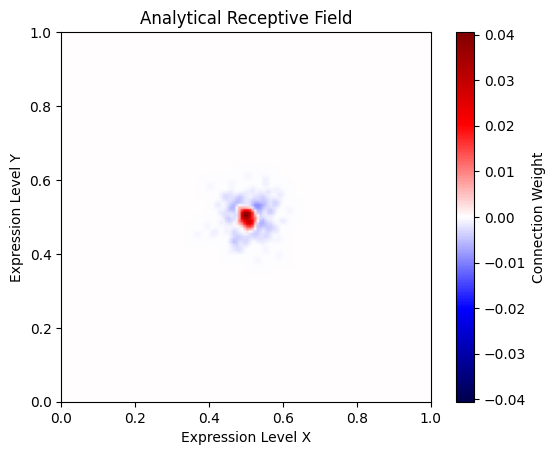

In [27]:
#############################
#       Analytical RF       #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)

print(f'Center index:{center_idx}')

W_eff_E = np.asarray(W_0_E[:, center_idx].todense()).ravel()
W_eff_I = np.asarray(W_0_I[:, center_idx].todense()).ravel()
W_eff   = W_eff_E + W_eff_I

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=1)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

Center index:12303


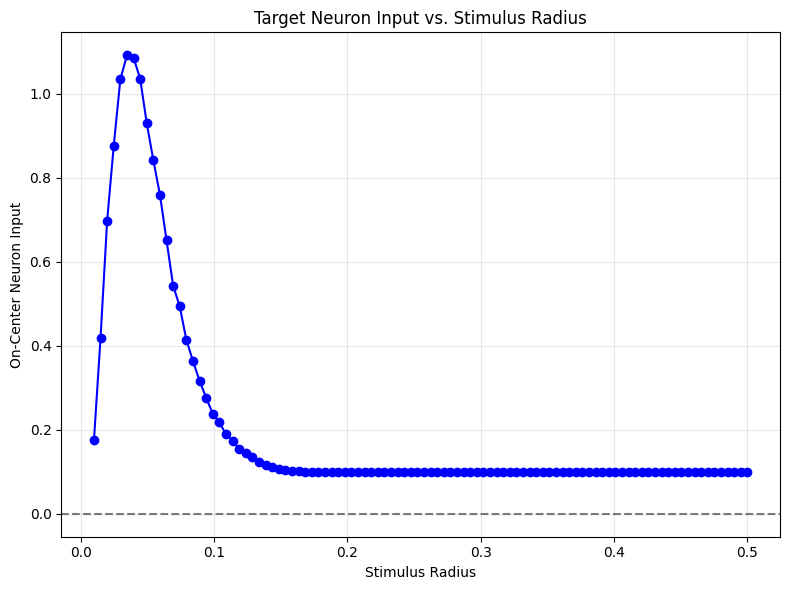

In [28]:
radii = np.linspace(0.01, 0.5, 100)
activities = []

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
print(f'Center index:{center_idx}')

r = 0.01

distances = np.linalg.norm(l_vals_L1_E - (0.5,0.5), axis=1)
indices = np.where(distances <= r)[0]


for r in radii:
    stim = apply_stimulus(r,coords=r_vals_L0_E)
    A_0 = stim
    A_1 = ReLU(A_0) @ W_0_E + ReLU(A_0) @ W_0_I
    acts = A_1[indices]
    activities.append(np.mean(acts, axis=0))

#print(A_1.shape)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# average = np.mean(A_0[indices], axis=0)

# print(f"Average of Neurons within: {average}")

In [ ]:
# target_x, target_y = 0.50, 0.50
# spatial_dist = np.sqrt((l_vals_L0_I[:, 0] - target_x)**2 + (l_vals_L0_I[:, 1] - target_y)**2)
# center_idx = np.argmin(spatial_dist)

# plot_spatial_prob_mask(
#      receiver_idx=center_idx,
#      prob_mask=W_00,
#      sender_coords=l_vals_L0_E,
#      receiver_coords=l_vals_L0_I,
#      title='',
#      vmin=-0.001,
#      vmax=0.001)

Center index:8518 with angle: 1.570796356364475


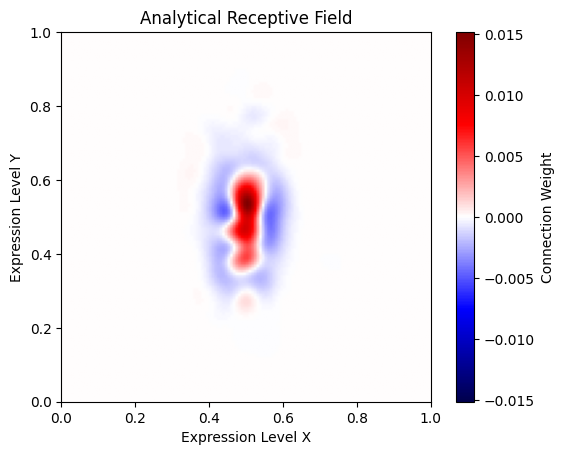

In [29]:
#############################
#       Analytical RF       #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L2[:, 0] - target_x)**2 + (l_vals_L2[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
print(f'Center index:{center_idx} with angle: {l_vals_L2[center_idx,2]}')

W0_full = (W_0_E + W_0_I).tocsr()

w1_col_E = W_1_E[:, center_idx]     
w1_col_I = W_1_I[:, center_idx]     

rf_via_E = 1 * np.asarray((W0_full @ w1_col_E).todense()).ravel()
rf_via_I = 1 * np.asarray((W0_full @ w1_col_I).todense()).ravel()
rf_total = rf_via_E + rf_via_I

true_rf = rf_total.reshape(n,n)
true_rf = gaussian_filter(true_rf, sigma=3)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

In [30]:

# plot_spatial_prob_mask(
#      receiver_idx=center_idx,
#      prob_mask=W_1_E,
#      sender_coords=l_vals_L1_E,
#      receiver_coords=l_vals_L2,
#      title='',
#      vmin=-0.001,
#      vmax=0.001)


# plot_spatial_prob_mask(
#      receiver_idx=center_idx,
#      prob_mask=W_1_I,
#      sender_coords=l_vals_L1_E,
#      receiver_coords=l_vals_L2,
#      title='',
#      vmin=-0.001,
#      vmax=0.001)



In [29]:
# #############################
# #        Find RWA RF        #
# #############################


# W0_full  = (W_0_E + W_0_I).tocsr()                              
# w1_col_E = np.asarray(W_1_E[:, center_idx].todense()).ravel()  
# w1_col_I = np.asarray(W_1_I[:, center_idx].todense()).ravel()  

# n_frames = 30000
# batch    = 2000                          
# rng      = np.random.default_rng(0)

# acc_E = np.zeros(N_L0_E)                  
# acc_I = np.zeros(N_L0_E)

# for start in range(0, n_frames, batch):
#     print(f'progress at {start}')
#     b      = min(batch, n_frames - start)
#     stim   = rng.standard_normal((b, N_L0_E))       
#     A1     = np.maximum(stim @ W0_full, 0.0)        
#     acts_E = A1 @ w1_col_E                            
#     acts_I = A1 @ w1_col_I                            
#     acc_E += acts_E @ stim
#     acc_I += acts_I @ stim

# rwa_via_E = acc_E / n_frames
# rwa_via_I = acc_I / n_frames
# rwa_total = rwa_via_E + rwa_via_I

# rwa_2d = gaussian_filter(rwa_total.reshape(n, n), sigma=1)
# vmax_rwa = np.max(np.abs(rwa_2d))

# fig, ax = plt.subplots()
# im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
# ax.set_title('RWA Receptive Field')
# ax.set_xlabel('Expression Level X')
# ax.set_ylabel('Expression Level Y')
# plt.colorbar(im0, ax=ax, label='Connection Weight')
# plt.show()

In [10]:
# #############################
# #        Line Stim          #
# #############################

# theta = np.radians(0)
# line_length = 0.2
# cx = 0.5
# cy = 0.5

# thickness = sig_0_E
# radius = 0.03
# stim_indices, center_x, center_y = get_indices_in_line(
#      coords, theta, thickness=thickness, length=line_length, cx=cx, cy=cy
# )
# print(stim_indices.sum())

# # L0 is a single excitatory population now, so the stimulus is just the mask
# # itself - no more concat([mask, mask]) for a separate L0_I input.
# mask = np.zeros(N_L0_E)
# mask[stim_indices] = 1
# A_0 = mask
# x_0 = l_vals_L0_E[:, 0]
# y_0 = l_vals_L0_E[:, 1]
# plot_stim_act(mask, x_0, y_0, title='Stimulus Layer', xlabel='Expression Level x', ylabel='Expression Level y', cbar_label='Input Level')


# # W_0 already folds in the L0_I surround helper (W_0 = direct + W_00 @ L0_I->L1_E),
# # so ReLU(A_0) @ W_0 IS the on-center layer's (L1_E) activity directly - no more
# # slicing A_1[0:N_L1_E] / A_1[N_L1_E:], since L1_I isn't a column of W_0 anymore.
# A_1 = ReLU(A_0) @ W_0_E + ReLU(A_0) @ W_0_I
# A_1_E = A_1

# x_1 = l_vals_L1_E[:, 0]
# y_1 = l_vals_L1_E[:, 1]

# plot_stim_act(A_1_E, x_1, y_1, title='(1) On-Center Cell Layer [Ligand Space]', xlabel='Expression Level x', ylabel='Expression Level y', cbar_label='Input Level')


# x_1 = r_vals_L1_E[:, 0]
# y_1 = r_vals_L1_E[:, 1]

# plot_stim_act(A_1_E, x_1, y_1, title='(1) On-Center Cell Layer [Receptor Space]', xlabel='Expression Level x', ylabel='Expression Level y', cbar_label='Input Level')


# # # L1_I is no longer a slice of A_1 - it's a separate population fed from the
# # # (rectified) on-center layer through the small-sigma relay W_11. Computing it
# # # here is only for visualization; W_1 below already accounts for its effect.
# # A_1_I = ReLU(A_1_E) @ W_11

# # x_1 = l_vals_L1_I[:, 0]
# # y_1 = l_vals_L1_I[:, 1]

# # plot_stim_act(A_1_I, x_1, y_1, title='(1) Inh On-Center Cell Layer [Ligand Space]', xlabel='Expression Level x', ylabel='Expression Level y', cbar_label='Input Level')


# # x_1 = r_vals_L1_I[:, 0]
# # y_1 = r_vals_L1_I[:, 1]

# # plot_stim_act(A_1_I, x_1, y_1, title='(1) Inh On-Center Cell Layer [Receptor Space]', xlabel='Expression Level x', ylabel='Expression Level y', cbar_label='Input Level')


# # # W_1 already folds in the L1_I surround helper the same way W_0 does for L0_I.
# # A_2 = ReLU(A_1_E) @ W_1

# # x_2 = l_vals_L2[:, 0]
# # y_2 = l_vals_L2[:, 1]
# # plot_stim_act(A_2, x_2, y_2, title='(2) Simple Cell Layer', xlabel='Expression Level x', ylabel='Expression Level y', cbar_label='Input Level')


3. Analyze net

Index: 7332
Location: x=0.498, y=0.507
Preferred Orientation: -0.0°



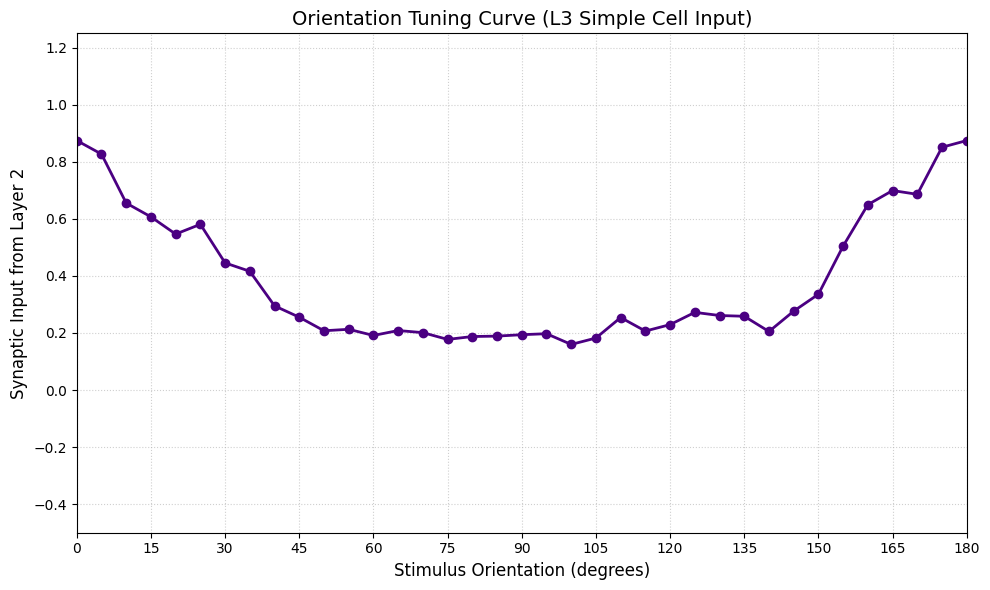

In [31]:
#############################
#  Orientation Tuning Curve #
#############################

target_x, target_y = 0.50, 0.50
target_theta = np.radians(0)

spatial_dist = np.sqrt((l_vals_L2[:, 0] - target_x)**2 + (l_vals_L2[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L2[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L2[target_idx, 0]:.3f}, y={l_vals_L2[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L2[target_idx, 2]):.1f}°\n")

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        coords, theta_stim, thickness=sig_0_E, length=0.2, cx=0.5, cy=0.5
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    target_cell_input = ReLU(A_1) @ W_1_E[:,target_idx] +  ReLU(A_1) @ W_1_I[:,target_idx]
    
    cell_inputs.append(target_cell_input)

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo', linewidth=2)

plt.title('Orientation Tuning Curve (L3 Simple Cell Input)', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Center index:0 with angle: 1.570808990608789


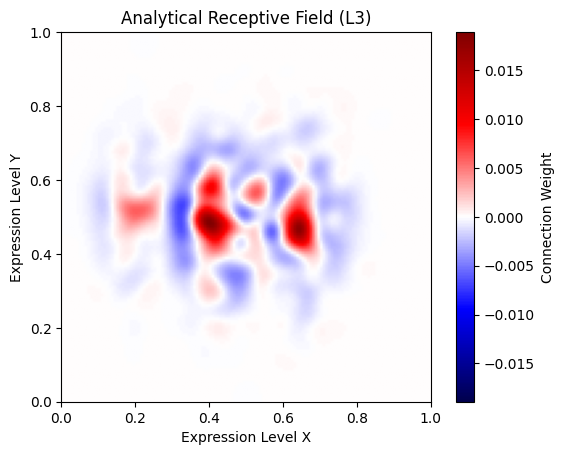

In [32]:
#############################
#       Analytical RF       #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L3[:, 0] - target_x)**2 + (l_vals_L3[:, 1] - target_y)**2)
l3_idx = np.argmin(spatial_dist)
print(f'Center index:{l3_idx} with angle: {l_vals_L3[l3_idx,2]}')

W0_full = (W_0_E + W_0_I).tocsr()     
W1_full = (W_1_E + W_1_I).tocsr()     
W2_full = W_2_E.tocsr()               

w2_col = W2_full[:, l3_idx]            

l1_via_E = W_1_E @ w2_col              
l1_via_I = W_1_I @ w2_col

rf_via_E = np.asarray((W0_full @ l1_via_E).todense()).ravel()
rf_via_I = np.asarray((W0_full @ l1_via_I).todense()).ravel()
rf_total = rf_via_E + rf_via_I

true_rf = rf_total.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=3)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field (L3)')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

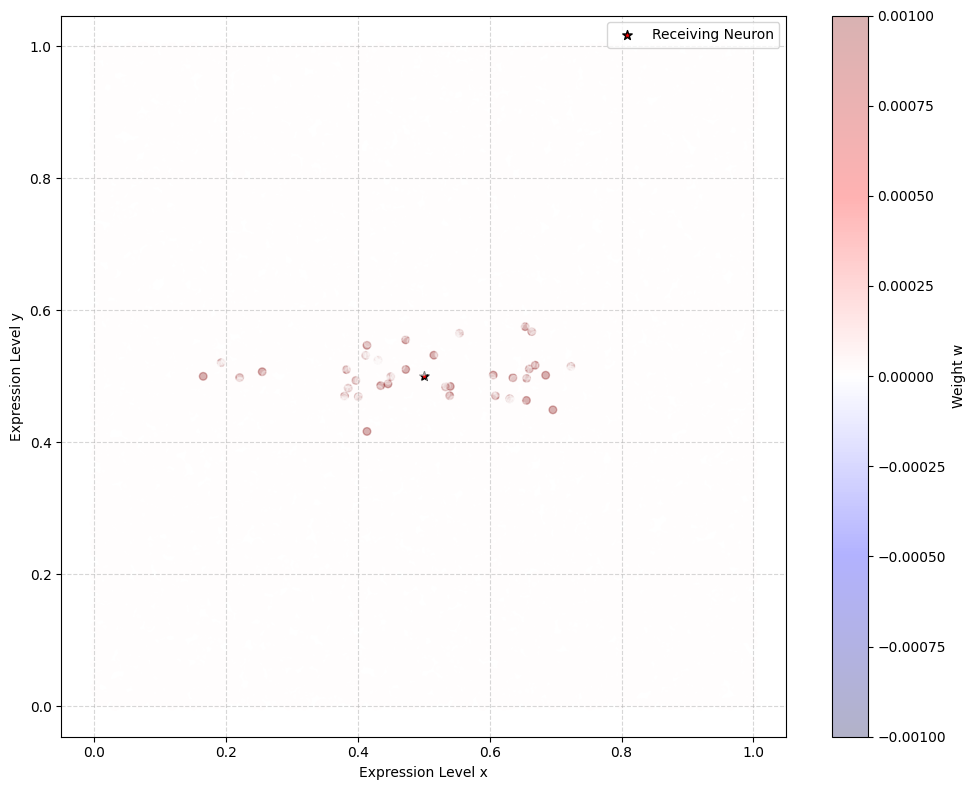

In [33]:
target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L3[:, 0] - target_x)**2 + (l_vals_L3[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)

plot_spatial_prob_mask(
     receiver_idx=center_idx,
     prob_mask=W_2_E_block,
     sender_coords=l_vals_L2_E,
     receiver_coords=l_vals_L3,
     title='',
     vmin=-0.001,
     vmax=0.001)

Complex cell (L2) idx 19900 @ [0.48790438 0.49250037], theta 0.000


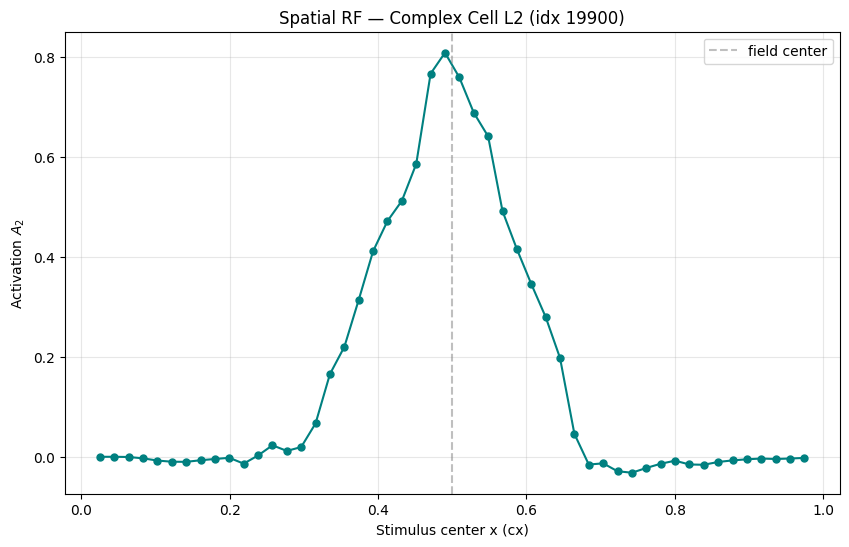

In [34]:
import matplotlib.pyplot as plt
import numpy as np

W_0 = (W_0_E + W_0_I).tocsr()
W_1 = (W_1_E + W_1_I).tocsr()
fwd = lambda a, W: np.asarray(a @ W).ravel()

# --- target: complex cell nearest center, tuned to the probe orientation ---
center_coords = np.array([0.49, 0.49])
theta_stim    = np.radians(0)

ang_pen  = np.abs(np.mod(l_vals_L2[:, 2] - theta_stim + np.pi/2, np.pi) - np.pi/2)
same_ori = np.where(ang_pen < np.pi/4)[0]
idx_L2   = same_ori[np.argmin(np.linalg.norm(l_vals_L2[same_ori, :2] - center_coords, axis=1))]
print(f"Complex cell (L2) idx {idx_L2} @ {l_vals_L2[idx_L2, :2]}, theta {l_vals_L2[idx_L2, 2]:.3f}")

# --- sweep the bar ---
n_steps     = 50
cx_vals     = np.linspace(0.025, 0.975, n_steps)
cy, line_length, thickness = 0.5, 0.2, 0.01

act_L2 = []
for cx in cx_vals:
    stim_indices, _, _ = get_indices_in_line(coords, theta_stim, thickness=thickness,
                                              length=line_length, cx=cx, cy=cy)
    A_0 = np.zeros(N_L0_E)
    A_0[stim_indices] = 1
    A_1 = fwd(ReLU(A_0), W_0)
    A_2 = fwd(ReLU(A_1), W_1)
    act_L2.append(A_2[idx_L2])

plt.figure(figsize=(10, 6))
plt.plot(cx_vals, act_L2, marker='o', ms=5, color='teal')
plt.title(f'Spatial RF — Complex Cell L2 (idx {idx_L2})')
plt.xlabel('Stimulus center x (cx)'); plt.ylabel('Activation $A_2$')
plt.axvline(0.5, color='gray', ls='--', alpha=0.5, label='field center')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

Integrator (L3) idx 0 @ [0.50000528 0.50001278], theta 1.571


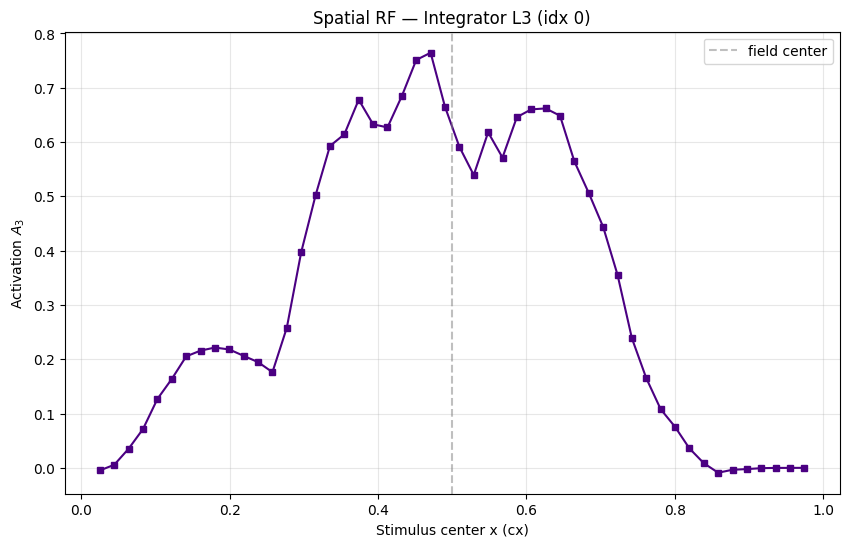

In [35]:
import matplotlib.pyplot as plt
import numpy as np

W_0 = (W_0_E + W_0_I).tocsr()
W_1 = (W_1_E + W_1_I).tocsr()
W_2 =  W_2_E.tocsr()
fwd = lambda a, W: np.asarray(a @ W).ravel()

# --- target: the readout neuron (single cell -> idx 0) ---
center_coords = np.array([0.49, 0.49])
theta_stim    = np.radians(0)
idx_L3 = np.argmin(np.linalg.norm(l_vals_L3[:, :2] - center_coords, axis=1))
print(f"Integrator (L3) idx {idx_L3} @ {l_vals_L3[idx_L3, :2]}, theta {l_vals_L3[idx_L3, 2]:.3f}")

# --- sweep the bar ---
n_steps     = 50
cx_vals     = np.linspace(0.025, 0.975, n_steps)
cy, line_length, thickness = 0.5, 0.2, 0.01

act_L3 = []
for cx in cx_vals:
    stim_indices, _, _ = get_indices_in_line(coords, theta_stim, thickness=thickness,
                                              length=line_length, cx=cx, cy=cy)
    A_0 = np.zeros(N_L0_E)
    A_0[stim_indices] = 1
    A_1 = fwd(ReLU(A_0), W_0)
    A_2 = fwd(ReLU(A_1), W_1)
    A_3 = fwd(A_2, W_2)          # no ReLU here — matches your original chain
    act_L3.append(A_3[idx_L3])

plt.figure(figsize=(10, 6))
plt.plot(cx_vals, act_L3, marker='s', ms=5, color='indigo')
plt.title(f'Spatial RF — Integrator L3 (idx {idx_L3})')
plt.xlabel('Stimulus center x (cx)'); plt.ylabel('Activation $A_3$')
plt.axvline(0.5, color='gray', ls='--', alpha=0.5, label='field center')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()